# Libraries

In [1]:
# Use with base (Python 3.13.2)
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import pingouin as pg
from pingouin import ancova
from matplotlib.patches import Patch
from statannotations.Annotator import Annotator
import xlsxwriter
import lxml

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols

from datetime import datetime
from __future__ import absolute_import, print_function

# Directories


In [2]:
ROOT = Path().resolve().parent      # one level up from current dir
hypercapnia_df_t2 = pd.read_csv(ROOT / "data/Hypercapnia/T2_results.csv")

# outDir = xxx # Set your output directory here and decomment your preferred image saving method at the end of the notebook.

# Prep the dataframes

In [3]:
T2 = hypercapnia_df_t2 

# Define a function to split the table in first session and both sessions
def extract_last_digit_and_filter(df, what):
    # Extract the last digit of the 'subID' column
    df['state'] = df['subject'].astype(str).str[-2]
    
    # Convert the last digit to integer type
    df['state'] = df['state'].apply(lambda x: "normocapnia" if x.startswith('N') else "hypercapnia")
    
    df['subID'] = df['subject'].astype(str).str[:-3]
    
    # Convert the last digit to integer type
    #df['subID'] = df['subID']
    
    if what == 'normo':
        #Create a new DataFrame with rows where 'session' equals 1
        original_name_normo = df[df['state'] == 'normocapnia'].copy()
    
        return original_name_normo
    else:
        #Create a new DataFrame with rows where 'session' equals 1
        original_name_hyper = df[df['state'] == 'hypercapnia'].copy()
    
        return original_name_hyper

# Extracting everything of interest out of the fMRI Dataframe
#T2 = T2[['subject', 'subID','state','rightLateralVentricle','bothVentricles','x3rdVentricle','x4thVentricle','csf']]
t2_normo = extract_last_digit_and_filter(T2,'normo')

# Add in Variable for whole cortex as a sum
t2_normo['wholeCortex'] = t2_normo['leftCerebralCortex'] + t2_normo['rightCerebralCortex']
t2_normo['wholeWM'] = t2_normo['leftCerebralWhiteMatter'] + t2_normo['rightCerebralWhiteMatter']
t2_normo['wholeParenchyma'] = t2_normo['wholeCortex'] + t2_normo['wholeWM']

# Add in Variable for deep GM as a sum
left_deepgm_cols = [
    "leftThalamus",
    "leftCaudate",
    "leftPutamen",
    "leftPallidum",
    "leftAmygdala",]
#]
right_deepgm_cols = [
    "rightThalamus",
    "rightCaudate",
    "rightPutamen",
    "rightPallidum",
    "rightAmygdala",]
#]

t2_normo["leftDeepGM"] = t2_normo[[c for c in left_deepgm_cols if c in t2_normo.columns]].sum(axis=1) \
    if any(c in t2_normo.columns for c in left_deepgm_cols) else 0

t2_normo["rightDeepGM"] = t2_normo[[c for c in right_deepgm_cols if c in t2_normo.columns]].sum(axis=1) \
    if any(c in t2_normo.columns for c in right_deepgm_cols) else 0

t2_normo["deepGM"] = t2_normo["leftDeepGM"] + t2_normo["rightDeepGM"]

# Add in Variable for SAS
t2_normo['SAS'] = t2_normo['csf'] - (t2_normo['bothVentricles'] + t2_normo['x3rdVentricle'] + t2_normo['x4thVentricle'])

# Drop out subjects
t2_normo = t2_normo[t2_normo['subID']!='sub-001'] # Has no fMRI
t2_normo = t2_normo[t2_normo['subID']!='sub-008'] # Head motion in fMRI
t2_normo = t2_normo[t2_normo['subID']!='sub-013'] # Head motion in fMRI
t2_normo = t2_normo[t2_normo['subID']!='sub-005'] # Wrong acquisition order


t2_hyper = extract_last_digit_and_filter(T2,'hyper')

# Add in Variable for whole cortex as a sum
t2_hyper['wholeCortex'] = t2_hyper['leftCerebralCortex'] + t2_hyper['rightCerebralCortex']
t2_hyper['wholeWM'] = t2_hyper['leftCerebralWhiteMatter'] + t2_hyper['rightCerebralWhiteMatter']
t2_hyper['wholeParenchyma'] = t2_hyper['wholeCortex'] + t2_hyper['wholeWM']

# Add in Variable for deep GM as a sum
t2_hyper["leftDeepGM"] = t2_hyper[[c for c in left_deepgm_cols if c in t2_hyper.columns]].sum(axis=1) \
    if any(c in t2_hyper.columns for c in left_deepgm_cols) else 0

t2_hyper["rightDeepGM"] = t2_hyper[[c for c in right_deepgm_cols if c in t2_hyper.columns]].sum(axis=1) \
    if any(c in t2_hyper.columns for c in right_deepgm_cols) else 0

t2_hyper["deepGM"] = t2_hyper["leftDeepGM"] + t2_hyper["rightDeepGM"]

# Add in Variable for SAS
t2_hyper['SAS'] = t2_hyper['csf'] - (t2_hyper['bothVentricles'] + t2_hyper['x3rdVentricle'] + t2_hyper['x4thVentricle'])

# Drop out subjects
t2_hyper = t2_hyper[t2_hyper['subID']!='sub-001'] # Has no fMRI
t2_hyper = t2_hyper[t2_hyper['subID']!='sub-008'] # Excessive Head Motion in fMRI
t2_hyper = t2_hyper[t2_hyper['subID']!='sub-013'] # Wrong Scanning acquisition
t2_hyper = t2_hyper[t2_hyper['subID']!='sub-005'] # Excessive Head Motion in fMRI

t2_both = pd.concat([t2_normo, t2_hyper])
    


pd.set_option('display.max_rows', None)



# Prep the dataframes - Normalization

In [4]:
# Normalize the dataframes
#del t2_hyper_norm
#del t2_normo_norm
#del t2_both_norm

# Global flag to check if normalization has been done
if 't2_normo_norm' not in globals():
    # Normalize df1 by dividing it by df2 (element-wise division)
    t2_normo_norm = t2_normo.select_dtypes(include='number') / t2_normo.select_dtypes(include='number')
    print("Normalization completed!")
else:
    print("Normalization already done!")

#print(t2_normo_norm)

# Global flag to check if normalization has been done
if 't2_hyper_norm' not in globals():
    # Normalize df1 by dividing it by df2 (element-wise division)
    # Align indexes first if needed or ignore index (element-wise division without aligning indices)
    t2_hyper_norm = t2_hyper.select_dtypes(include='number').reset_index(drop=True) / \
                    t2_normo.select_dtypes(include='number').reset_index(drop=True)
    print("Normalization completed!")
else:
    print("Normalization already done!")


# Calculate absolute difference in ventricle_volume
if 't2_both_norm' not in globals():
    t2_both_norm = pd.concat([t2_normo_norm, t2_hyper_norm])
    t2_both_norm[['subID', 'state', 'subject']] = t2_both[['subID', 'state', 'subject']].values


Normalization completed!
Normalization completed!


# Edit the RC file

In [5]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue"],
    "svg.fonttype": "none"
})

# Figure subcortical GM, WM and subarachnoid CSF

T-statistic: -1.4202585482869303
P-value: 0.18324999771869474
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

normocapnia vs. hypercapnia: ns
T-statistic: -2.3400767794709316
P-value: 0.03916698842241399
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

normocapnia vs. hypercapnia: *
SAS T-statistic: 4.334727294051973
SAS P-value: 0.0011851756619330875
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

normocapnia vs. hypercapnia: **


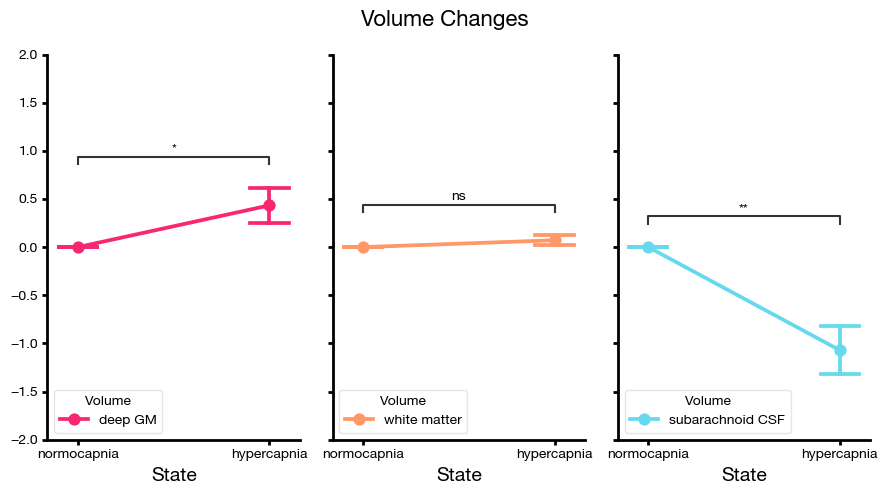

In [6]:
#del t2_structural_catplot
t2_structural_catplot = pd.DataFrame()
t2_structural_catplot['percentage_wm'] = (t2_both_norm['wholeWM'] - 1) * 100
t2_structural_catplot['label_wm'] = 'white matter'
t2_structural_catplot['percentage_deepGM'] = (t2_both_norm['deepGM'] - 1) * 100
t2_structural_catplot['label_deepGM'] = 'deep GM'
t2_structural_catplot["percentage_sas"] = (t2_both_norm["SAS"] - 1) * 100
t2_structural_catplot["label_sas"] = "subarachnoid CSF"

t2_structural_catplot['State'] = t2_both_norm['state']
t2_structural_catplot['subID'] = t2_both_norm['subID']


 # Palette for GM
monokai_pro_palette_gm = [
    (249, 38, 114),   # Red

]
# Convert RGB values to a format Seaborn understands (scaled between 0 and 1)
monokai_pro_palette_gm = [(r / 255, g / 255, b / 255) for r, g, b in monokai_pro_palette_gm]

 # Palette for WM
monokai_pro_palette_wm = [
    (255,151,103),   # Orange

]
# Convert RGB values to a format Seaborn understands (scaled between 0 and 1)
monokai_pro_palette_wm = [(r / 255, g / 255, b / 255) for r, g, b in monokai_pro_palette_wm]
 
 # Palette for CSF
monokai_pro_palette_csf = [
    (102, 217, 239),  # Blue

]
# Convert RGB values to a format Seaborn understands (scaled between 0 and 1)
monokai_pro_palette_csf = [(r / 255, g / 255, b / 255) for r, g, b in monokai_pro_palette_csf]
 
 
fig, axes = plt.subplots(1, 3, figsize=(9, 5), sharey=True)

# Add a central title for the entire figure
fig.suptitle("Volume Changes", fontsize=16, weight='bold')

# Cortex volume change
sns.pointplot(
    ax=axes[1],
    data=t2_structural_catplot,
    x="State",
    hue="label_wm",
    y="percentage_wm",
    palette=monokai_pro_palette_wm,
    capsize=0.2,
    errorbar="se",
    #label="Cortical GM"
)
axes[1].set_ylabel('Percentage Volume Change [%]', fontsize=14)
axes[1].set_xlabel('State', fontsize=14)
axes[1].set_ylim(-2, 2) 
axes[1].legend(loc="lower left", title="Volume",framealpha=0.5)
plt.tight_layout()
sns.despine()
# Annotate the Cortex plot
cortex_pairs = [("normocapnia", "hypercapnia")]
annotator = Annotator(axes[1], cortex_pairs, data=t2_structural_catplot, x="State", y="percentage_wm")

# Perform statistical testing between groups
# Extract data for group1 where State == "Normocapnia"
group1 = t2_structural_catplot.loc[t2_structural_catplot['State'] == "normocapnia", 'percentage_wm']

# Extract data for group2 where State == "Hypercapnia"
group2 = t2_structural_catplot.loc[t2_structural_catplot['State'] == "hypercapnia", 'percentage_wm']

# Perform paired t-test
t_stat, p_value = stats.ttest_rel(group1, group2)

# Display the results
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

rounded_p_value = round(p_value, 2)
rounded_p_value_str = f"$\\it{{p}} = {rounded_p_value}$"  # Using LaTeX for 'p'

# Initialize an empty list to store formatted p-values
formatted_pvalues_list = []

# Format p-value for annotation
if p_value <= 1e-4:
    formatted_pvalue = '****'
elif p_value <= 1e-3:
    formatted_pvalue = '***'
elif p_value <= 1e-2:
    formatted_pvalue = '**'
elif p_value <= 5e-2:
    formatted_pvalue = '*'
else:
    formatted_pvalue = 'ns'

# Set custom annotations for the pairs
pairs = [('normocapnia', 'hypercapnia')]  # Ensure correct pair naming
formatted_pvalues_list.append(formatted_pvalue)

annotator.set_custom_annotations([formatted_pvalue])
annotator.annotate()

# Ventricles volume change
sns.pointplot(
    ax=axes[0],
    data=t2_structural_catplot,
    x="State",
    hue="label_deepGM",
    y="percentage_deepGM",
    palette=monokai_pro_palette_gm,
    capsize=0.2,
    errorbar="se",
    #label="Lateral Ventricles"
)
axes[0].set_xlabel('State', fontsize=14)
axes[0].set_ylabel("")
axes[0].legend(loc="lower left", title="Volume",framealpha=0.5)
plt.tight_layout()

# Annotate the Ventricles plot
ventricles_pairs = [("normocapnia", "hypercapnia")]
annotator = Annotator(axes[0], ventricles_pairs, data=t2_structural_catplot, x="State", y="percentage_deepGM")
# Perform statistical testing between groups
# Extract data for group1 where State == "Normocapnia"
group1 = t2_structural_catplot.loc[t2_structural_catplot['State'] == "normocapnia", 'percentage_deepGM']

# Extract data for group2 where State == "Hypercapnia"
group2 = t2_structural_catplot.loc[t2_structural_catplot['State'] == "hypercapnia", 'percentage_deepGM']

# Perform paired t-test
t_stat, p_value = stats.ttest_rel(group1, group2)

# Display the results
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

rounded_p_value = round(p_value, 2)
rounded_p_value_str = f"$\\it{{p}} = {rounded_p_value}$"  # Using LaTeX for 'p'

# Initialize an empty list to store formatted p-values
formatted_pvalues_list = []

# Format p-value for annotation
if p_value <= 1e-4:
    formatted_pvalue = '****'
elif p_value <= 1e-3:
    formatted_pvalue = '***'
elif p_value <= 1e-2:
    formatted_pvalue = '**'
elif p_value <= 5e-2:
    formatted_pvalue = '*'
else:
    formatted_pvalue = 'ns'

# Set custom annotations for the pairs
pairs = [('normocapnia', 'hypercapnia')]  # Ensure correct pair naming
formatted_pvalues_list.append(formatted_pvalue)

annotator.set_custom_annotations([formatted_pvalue])
annotator.annotate()


sns.pointplot(
    ax=axes[2],
    data=t2_structural_catplot,
    x="State",
    hue="label_sas",
    y="percentage_sas",
    palette=monokai_pro_palette_csf,
    capsize=0.2,
    errorbar="se",
)
axes[2].set_xlabel("State", fontsize=14)
axes[2].set_ylabel("")
axes[2].legend(loc="lower left", title="Volume", framealpha=0.5)

# Annotate SAS
annotator = Annotator(axes[2], pairs, data=t2_structural_catplot, x="State", y="percentage_sas")

group1 = t2_structural_catplot.loc[t2_structural_catplot["State"] == "normocapnia", "percentage_sas"]
group2 = t2_structural_catplot.loc[t2_structural_catplot["State"] == "hypercapnia", "percentage_sas"]
t_stat, p_value = stats.ttest_rel(group1, group2)

print(f"SAS T-statistic: {t_stat}")
print(f"SAS P-value: {p_value}")

if p_value <= 1e-4:
    formatted_pvalue = "****"
elif p_value <= 1e-3:
    formatted_pvalue = "***"
elif p_value <= 1e-2:
    formatted_pvalue = "**"
elif p_value <= 5e-2:
    formatted_pvalue = "*"
else:
    formatted_pvalue = "ns"

annotator.set_custom_annotations([formatted_pvalue])
annotator.annotate()

# Set all axes and tick linewidths
for ax in axes:
    ax.tick_params(axis='both', width=2)
    for spine in ax.spines.values():
        spine.set_linewidth(2)

plt.show()
 
 
# Save the figure -------
#image_path = os.path.join(outDir, f'GM_Ventricle_Pointplot.png')
#fig.savefig(image_path,dpi=300, bbox_inches='tight')
#---
#image_path_svg = os.path.join(outDir, f'GM_Ventricle_Pointplot.svg')
#fig.savefig(image_path_svg)